In [1]:
# ============================================================
# Cell 1: Imports
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("All imports successful")

All imports successful


In [2]:
# ============================================================
# Cell 2: Device + Config
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

BATCH_SIZE         = 64
CLASSIFIER_EPOCHS  = 15
DAE_EPOCHS         = 20
FINETUNE_EPOCHS    = 5
LR_HEAD            = 1e-3
LR_BACKBONE        = 1e-4
LR_DAE             = 1e-3

Using device: cuda


In [3]:
# ============================================================
# Cell 3: Transforms
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print("Transforms defined")

Transforms defined


In [4]:
# ============================================================
# Cell 4: Datasets & Loaders
# ============================================================
train_dataset = datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_transform)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

classes = train_dataset.classes
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {classes}")

100%|██████████| 170M/170M [00:04<00:00, 38.8MB/s] 


Train: 50000 | Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
# ============================================================
# Cell 5: Helpers — Denormalize / Normalize / Noise
# ============================================================
def denormalize(img):
    mean_t = torch.tensor(MEAN).view(1,3,1,1).to(img.device)
    std_t  = torch.tensor(STD ).view(1,3,1,1).to(img.device)
    return img * std_t + mean_t

def normalize(img):
    mean_t = torch.tensor(MEAN).view(1,3,1,1).to(img.device)
    std_t  = torch.tensor(STD ).view(1,3,1,1).to(img.device)
    return (img - mean_t) / std_t

def add_noise(images, noise_level):
    if noise_level == 0.0:
        return images
    return torch.clamp(images + torch.randn_like(images) * noise_level, 0.0, 1.0)

print("Helpers defined")

Helpers defined


In [6]:
# ============================================================
# Cell 6: FastDAE Architecture
# ============================================================
class FastDAE(nn.Module):
    """
    Lightweight 3-level U-Net DAE.
    Operates at 64x64 internally — fast and accurate enough.
    ~300K params vs 8M in the ResUNet version.
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3,  32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )
        # Decoder
        self.dec1  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.fuse1 = nn.Conv2d(128, 64, 1)   # 64 up + 64 skip → 64

        self.dec2  = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.fuse2 = nn.Conv2d(64, 32, 1)    # 32 up + 32 skip → 32

        self.dec3  = nn.Sequential(
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        d1 = self.fuse1(torch.cat([self.dec1(e3), e2], dim=1))
        d2 = self.fuse2(torch.cat([self.dec2(d1), e1], dim=1))
        return self.dec3(d2)


# ── Universal denoise helper — handles the 64×64 resize internally ────────────
def denoise(dae, clean_images):
    """
    Resize to 64×64 → run DAE → resize back to original resolution.
    Use this everywhere instead of calling dae() directly.
    """
    orig_size = clean_images.shape[-1]
    small     = F.interpolate(clean_images, (64, 64), mode="bilinear", align_corners=False)
    denoised  = torch.clamp(dae(small), 0, 1)
    return F.interpolate(denoised, (orig_size, orig_size), mode="bilinear", align_corners=False)


autoencoder = FastDAE().to(device)
params = sum(p.numel() for p in autoencoder.parameters())
print(f"FastDAE params: {params:,}")

FastDAE params: 197,347


In [7]:
# ============================================================
# Cell 7: Train DAE
# ============================================================
def train_dae(dae, loader, epochs=DAE_EPOCHS, patience=4):
    optimizer = optim.Adam(dae.parameters(), lr=LR_DAE, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    use_amp = device.type == "cuda"
    scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_loss, best_state, counter = float("inf"), None, 0
    history = []

    def get_noise_config(epoch):
        if epoch < 5:
            return [0.05, 0.1, 0.2],          [0.50, 0.35, 0.15]
        elif epoch < 12:
            return [0.1,  0.2, 0.3, 0.4],     [0.30, 0.30, 0.25, 0.15]
        else:
            return [0.1,  0.2, 0.3, 0.4, 0.5],[0.20, 0.25, 0.25, 0.20, 0.10]

    for epoch in range(epochs):
        dae.train()
        total_loss = 0.0
        noise_levels, probs = get_noise_config(epoch)

        for images, _ in loader:
            images = images.to(device)

            # Work at 64×64 — 12× faster than 224×224
            clean = denormalize(images)
            clean = F.interpolate(clean, (64, 64), mode="bilinear", align_corners=False)
            nl    = float(np.random.choice(noise_levels, p=probs))
            noisy = add_noise(clean, nl)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp):
                output = torch.clamp(dae(noisy), 0, 1)
                loss   = 0.8 * F.l1_loss(output, clean) + 0.2 * F.mse_loss(output, clean)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(dae.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        avg = total_loss / len(loader)
        history.append(avg)
        scheduler.step(avg)
        print(f"DAE Epoch {epoch+1:>2}/{epochs}  Loss: {avg:.4f}  "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        if avg < best_loss:
            best_loss  = avg
            best_state = {k: v.clone() for k, v in dae.state_dict().items()}
            counter    = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (best: {best_loss:.4f})")
                break

    dae.load_state_dict(best_state)
    print(f"\n✅ DAE done. Best loss: {best_loss:.4f}")
    return history


dae_history = train_dae(autoencoder, train_loader, epochs=DAE_EPOCHS)

/tmp/ipykernel_55/3390697453.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_55/3390697453.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


DAE Epoch  1/20  Loss: 0.0305  LR: 1.00e-03
DAE Epoch  2/20  Loss: 0.0227  LR: 1.00e-03
DAE Epoch  3/20  Loss: 0.0216  LR: 1.00e-03
DAE Epoch  4/20  Loss: 0.0211  LR: 1.00e-03
DAE Epoch  5/20  Loss: 0.0202  LR: 1.00e-03
DAE Epoch  6/20  Loss: 0.0296  LR: 1.00e-03
DAE Epoch  7/20  Loss: 0.0279  LR: 1.00e-03
DAE Epoch  8/20  Loss: 0.0274  LR: 5.00e-04
DAE Epoch  9/20  Loss: 0.0261  LR: 5.00e-04
Early stopping at epoch 9 (best: 0.0202)

✅ DAE done. Best loss: 0.0202


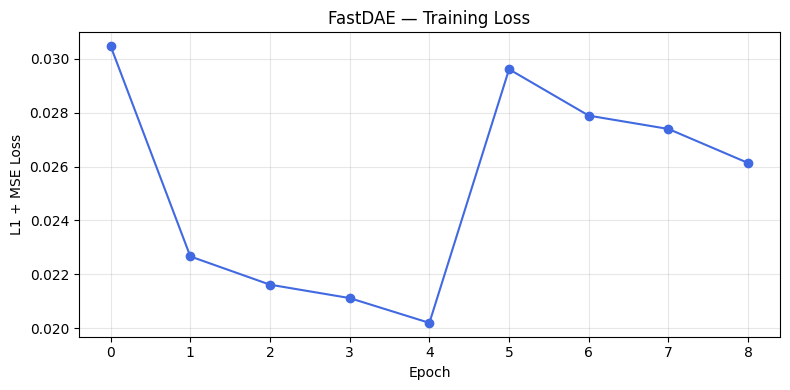

In [8]:
# ============================================================
# Cell 8: DAE Loss Curve
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(dae_history, marker="o", color="royalblue")
plt.xlabel("Epoch")
plt.ylabel("L1 + MSE Loss")
plt.title("FastDAE — Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

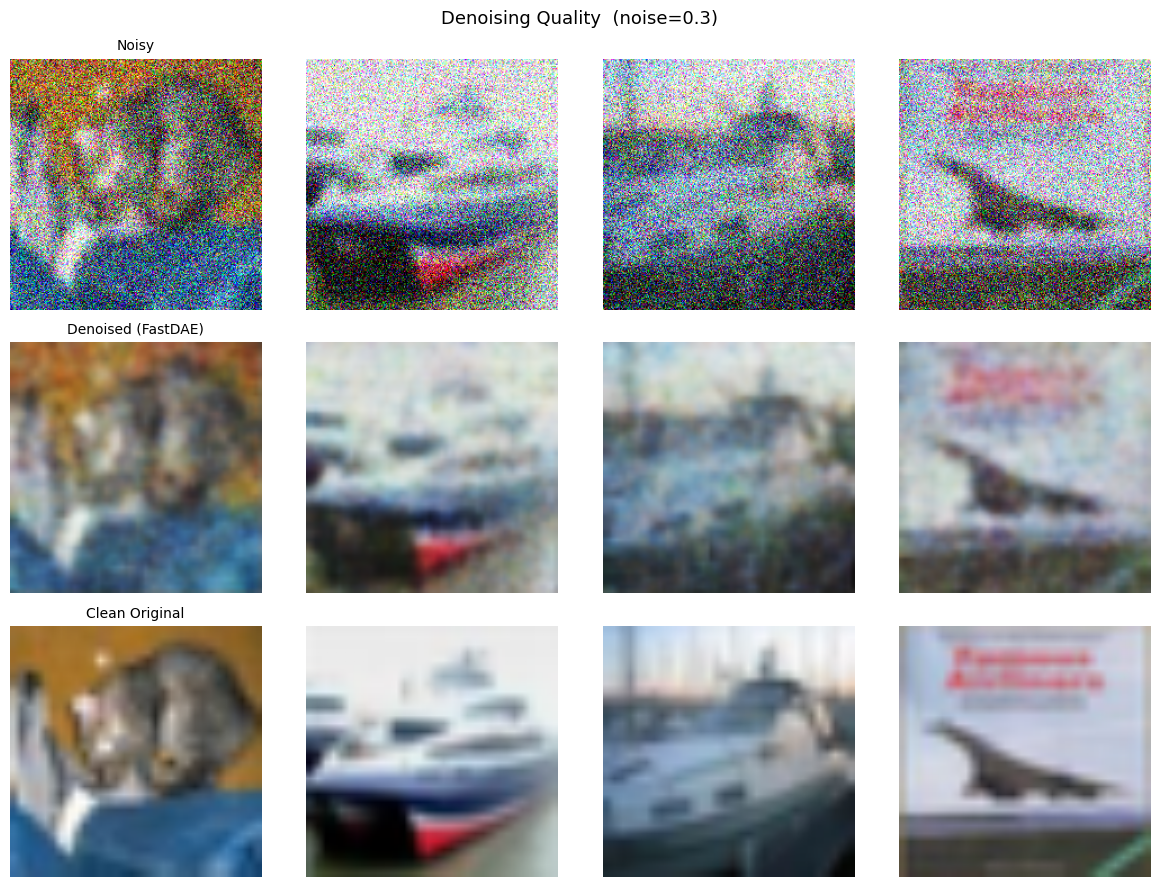

In [9]:
# ============================================================
# Cell 9: DAE Visual Quality Check
# ============================================================
def show_denoising(dae, images, noise_level=0.3):
    dae.eval()
    clean = denormalize(images.clone())
    noisy = add_noise(clean, noise_level)

    with torch.no_grad():
        denoised = denoise(dae, noisy)   # uses the helper

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    row_titles = ["Noisy", "Denoised (FastDAE)", "Clean Original"]

    for col in range(4):
        for row, (batch, title) in enumerate(zip([noisy, denoised, clean], row_titles)):
            ax = axes[row, col]
            ax.imshow(batch[col].cpu().numpy().transpose(1, 2, 0).clip(0, 1))
            if col == 0:
                ax.set_title(title, fontsize=10)
            ax.axis("off")

    plt.suptitle(f"Denoising Quality  (noise={noise_level})", fontsize=13)
    plt.tight_layout()
    plt.show()


sample_images, _ = next(iter(test_loader))
show_denoising(autoencoder, sample_images.to(device), noise_level=0.3)

In [10]:
# ============================================================
# Cell 10: Classifier — Full Fine-Tuning with Differential LRs
# ============================================================
classifier = models.resnet18(pretrained=True)
classifier.fc = nn.Linear(classifier.fc.in_features, 10)
classifier = classifier.to(device)

backbone_params = [p for name, p in classifier.named_parameters() if "fc" not in name]
head_params     = list(classifier.fc.parameters())

optimizer_clf = optim.Adam([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": head_params,     "lr": LR_HEAD},
], weight_decay=1e-4)

scheduler_clf = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_clf, T_max=CLASSIFIER_EPOCHS, eta_min=1e-6
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

total = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Classifier trainable params: {total:,}  (full fine-tuning)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s] 

Classifier trainable params: 11,181,642  (full fine-tuning)


In [11]:
# ============================================================
# Cell 11: Noise-Aware Classifier Training
# ============================================================
def train_classifier(model, dae, loader, optimizer, scheduler, epochs, p_augment=0.3):
    train_losses, train_accs = [], []

    for epoch in range(epochs):
        model.train()
        dae.eval()
        running_loss = correct = total = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # 30% of batches: add noise → denoise → feed to classifier
            if np.random.rand() < p_augment:
                with torch.no_grad():
                    nl       = float(np.random.choice([0.1, 0.2, 0.3], p=[0.5, 0.3, 0.2]))
                    clean    = denormalize(images)
                    noisy    = add_noise(clean, nl)
                    denoised = denoise(dae, noisy)   # helper handles resize
                    images   = normalize(denoised)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        scheduler.step()

        avg_loss = running_loss / len(loader)
        acc      = 100.0 * correct / total
        train_losses.append(avg_loss)
        train_accs.append(acc)
        print(f"Epoch {epoch+1:>2}/{epochs}  Loss: {avg_loss:.4f}  "
              f"Acc: {acc:.2f}%  LR(head): {optimizer.param_groups[1]['lr']:.2e}")

    return train_losses, train_accs


print("Starting noise-aware classifier training...")
clf_losses, clf_accs = train_classifier(
    classifier, autoencoder, train_loader,
    optimizer_clf, scheduler_clf, epochs=CLASSIFIER_EPOCHS
)

Starting noise-aware classifier training...
Epoch  1/15  Loss: 0.8988  Acc: 84.48%  LR(head): 9.89e-04
Epoch  2/15  Loss: 0.7506  Acc: 90.67%  LR(head): 9.57e-04
Epoch  3/15  Loss: 0.7039  Acc: 92.63%  LR(head): 9.05e-04
Epoch  4/15  Loss: 0.6727  Acc: 93.83%  LR(head): 8.35e-04
Epoch  5/15  Loss: 0.6438  Acc: 94.87%  LR(head): 7.50e-04
Epoch  6/15  Loss: 0.6199  Acc: 95.89%  LR(head): 6.55e-04
Epoch  7/15  Loss: 0.5978  Acc: 96.71%  LR(head): 5.53e-04
Epoch  8/15  Loss: 0.5874  Acc: 97.09%  LR(head): 4.48e-04
Epoch  9/15  Loss: 0.5688  Acc: 97.69%  LR(head): 3.46e-04
Epoch 10/15  Loss: 0.5673  Acc: 97.69%  LR(head): 2.51e-04
Epoch 11/15  Loss: 0.5537  Acc: 98.21%  LR(head): 1.66e-04
Epoch 12/15  Loss: 0.5507  Acc: 98.33%  LR(head): 9.64e-05
Epoch 13/15  Loss: 0.5445  Acc: 98.53%  LR(head): 4.42e-05
Epoch 14/15  Loss: 0.5407  Acc: 98.70%  LR(head): 1.19e-05
Epoch 15/15  Loss: 0.5389  Acc: 98.77%  LR(head): 1.00e-06


In [12]:
# ============================================================
# Cell 12: Evaluate Clean Accuracy
# ============================================================
def evaluate(model, loader):
    model.eval()
    running_loss = correct = total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100.0 * correct / total
    return running_loss / len(loader), acc, all_preds, all_labels


val_loss, val_acc, preds, true_labels = evaluate(classifier, test_loader)
print(f"\n✅ Clean Test Accuracy: {val_acc:.2f}%")


✅ Clean Test Accuracy: 96.61%


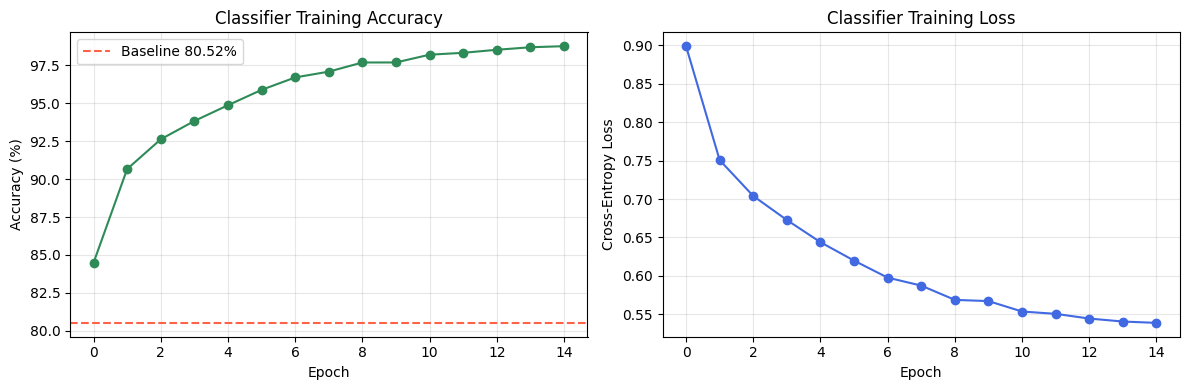

In [13]:
# ============================================================
# Cell 13: Training Curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(clf_accs, marker="o", color="seagreen")
ax1.axhline(80.52, linestyle="--", color="tomato", label="Baseline 80.52%")
ax1.set_title("Classifier Training Accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(clf_losses, marker="o", color="royalblue")
ax2.set_title("Classifier Training Loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Cross-Entropy Loss")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

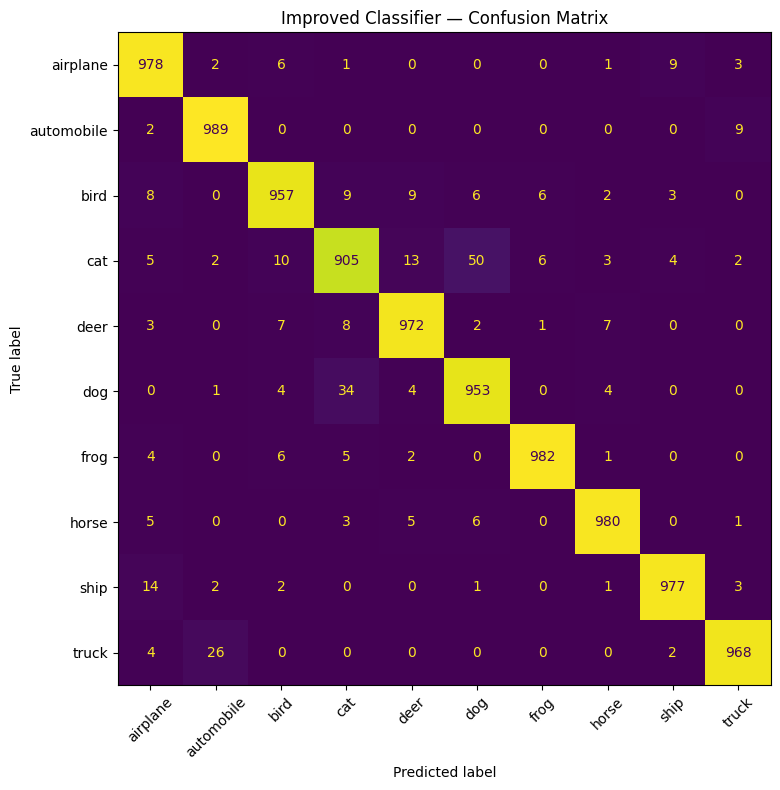

In [14]:
# ============================================================
# Cell 14: Confusion Matrix
# ============================================================
_, _, preds, true_labels = evaluate(classifier, test_loader)

cm   = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Improved Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Cell 15: Full Pipeline Evaluation
# ============================================================
def evaluate_full_pipeline(clf, dae, loader, noise_level):
    clf.eval(); dae.eval()
    correct = total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if noise_level == 0.0:
                processed = images
            else:
                clean     = denormalize(images)
                noisy     = add_noise(clean, noise_level)
                denoised  = denoise(dae, noisy)      # helper handles resize
                processed = normalize(denoised)

            _, predicted = clf(processed).max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100.0 * correct / total


noise_levels = [0.0, 0.1, 0.3, 0.5, 0.7]

baseline_no_dae   = {0.0: 80.52, 0.1: 15.95, 0.3: 10.00, 0.5:  9.61, 0.7: 8.71}
baseline_with_dae = {0.0: 80.52, 0.1: 58.37, 0.3: 39.82, 0.5: 19.67, 0.7: None}

improved_results = {}
print("=" * 58)
print(f"{'Noise':>8}  {'No DAE':>10}  {'Baseline+DAE':>14}  {'Improved':>10}")
print("=" * 58)

for nl in noise_levels:
    acc = evaluate_full_pipeline(classifier, autoencoder, test_loader, nl)
    improved_results[nl] = acc
    b0  = f"{baseline_no_dae[nl]:.2f}%"
    b1  = f"{baseline_with_dae[nl]:.2f}%" if baseline_with_dae[nl] else "N/A"
    print(f"{nl:>8}  {b0:>10}  {b1:>14}  {acc:>9.2f}%")

print("=" * 58)

   Noise      No DAE    Baseline+DAE    Improved
     0.0      80.52%          80.52%      96.61%
     0.1      15.95%          58.37%      93.59%
     0.3      10.00%          39.82%      77.15%
     0.5       9.61%          19.67%      42.11%
     0.7       8.71%             N/A      23.00%


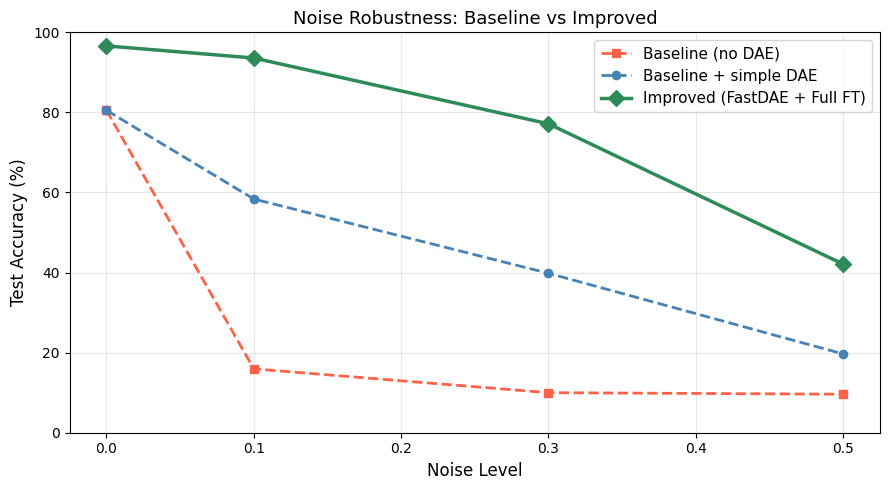

In [16]:
# ============================================================
# Cell 16: Comparison Plot
# ============================================================
nl_common = [0.0, 0.1, 0.3, 0.5]

b_no_dae = [baseline_no_dae[nl]   for nl in nl_common]
b_dae    = [baseline_with_dae[nl] for nl in nl_common]
improved = [improved_results[nl]  for nl in nl_common]

plt.figure(figsize=(9, 5))
plt.plot(nl_common, b_no_dae,  "s--", color="tomato",    label="Baseline (no DAE)",         linewidth=2)
plt.plot(nl_common, b_dae,     "o--", color="steelblue", label="Baseline + simple DAE",      linewidth=2)
plt.plot(nl_common, improved,  "D-",  color="seagreen",  label="Improved (FastDAE + Full FT)",linewidth=2.5, markersize=8)

plt.xlabel("Noise Level", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Noise Robustness: Baseline vs Improved", fontsize=13)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.ylim(0, 100)
plt.tight_layout()
plt.show()